# <img style="float: left; padding-right: 15px; width: 35px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png"> CS 1090B: Advanced Topics in Data Science 

# Homework 4: Sequence Models, Language Modeling, NER, and Transformers

**Harvard University**<br/>
**Spring 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, Chris Gumb

<hr style="height:2pt">


<div style="background-color:#fff3cd; color:#222222; border:1px solid #ffeeba; padding:12px 14px; border-radius:10px; margin:10px 0;">
<strong>Run environment:</strong> This homework is designed to be run on a <strong>GPU-enabled environment</strong> such as the course cluster.
The Edward Lear text excerpts and abstract CSV files should live in the notebook's local <code>data/</code> directory.
</div>


<div style="background-color:#d1ecf1; color:#222222; border:1px solid #bee5eb; padding:12px 14px; border-radius:10px; margin:10px 0;">
<strong>Reproducibility / efficiency expectation:</strong> You are expected to write code that <strong>saves</strong> trained model weights
(and any other expensive artifacts) to disk and <strong>loads</strong> them on reruns to avoid unnecessary retraining.
Your notebook should run quickly after the first successful training run.
</div>


## Notebook Contents
<a id = "contents"></a>

- [**Part I: Character-Level Language Modeling**](#part1):
  Text generation in the style of Edward Lear with a PyTorch recurrent network

- [**Part II: Named Entity Recognition**](#part2):
  Sequence tagging with a bidirectional GRU in PyTorch

- [**Part III: Transformer-Based Text Classification**](#part3):
  Fine-tuning BERT (and optionally DeBERTa for 209 students) in PyTorch


In [1]:
# Standard library
import gc
import math
import os
import pickle
import random
import re
import time
import warnings
from pathlib import Path

# Numerical computing and data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset, TensorDataset

# Transformers
import transformers
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Suppress warnings
warnings.filterwarnings("ignore")

SEED = 1090
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_ROOT = Path("./data")
ARTIFACTS_DIR = Path("./artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

print("device:", DEVICE)
print("transformers version:", transformers.__version__)

device: cuda
transformers version: 4.37.0


In [2]:
# measure notebook runtime
time_start = time.time()

<a id="part1"></a>

## Part I: Character-Level Language Modeling

In this part, you will build a character-level language model that generates text in the style of Edward Lear.
The overall modeling problem is to predict the next character given a sequence of previous characters.
You will preprocess the corpus, create integer encodings, construct PyTorch data pipelines, train a recurrent model,
and assess the quality of its generated text using both qualitative samples and perplexity.


### Q1.1 - Reading & Cleaning the Text

Read the contents of the file `data/edward_lear.txt` and store it in a variable called `text_raw`. The text contained in this file is an excerpt of content made available thanks to [Project Gutenberg](https://www.gutenberg.org/) and is distributed under their licence. Project Gutenberg is a great place to find texts for NLP projects.

*(The full text they distribute, `data/pg13650.txt`, is included in our files to adhere to their licence.)*

Next, implement a function `text_clean` that converts a string to lowercase and replaces any number of contiguous whitespace characters with a single space (for example, `\n\n` should become `' '`). Use it on `text_raw` and save the result as `text`.

Afterward, print the length of the cleaned corpus.


In [3]:
with open(DATA_ROOT / "edward_lear.txt", "r", encoding="utf-8") as f:
    text_raw = f.read()

def text_clean(raw):
    cleaned = re.sub(r'\[.*?\]', '', raw)  # No bracketed annotations
    cleaned = re.sub(r'\s+', ' ', cleaned)  # Multiple whitespace to single space
    cleaned = cleaned.lower().strip()  # Lowercase
    return cleaned

text = text_clean(text_raw)

In [4]:
# Display length of cleaned corpus
print("Length of cleaned corpus:", len(text))
print(text[:300])

Length of cleaned corpus: 126805
a book of nonsense by edward lear. with all the original pictures and verses there was an old derry down derry, who loved to see little folks merry; so he made them a book, and with laughter they shook at the fun of that derry down derry. original dedication. to the great-grandchildren, grand-nephew


### Q1.2 - Character-Integer Mappings

We will be building a character-level language model. Instead of treating words as tokens, we will treat each individual character as a token.

Create a sorted list called `chars` of all unique characters in `text`. Then create two dictionaries:
- `char2idx`, mapping each character to the integer index at which it appears in `chars`
- `idx2char`, mapping each integer index back to its corresponding character

Store the size of the character vocabulary as `n_chars` and print it.


In [5]:
chars = sorted(list(set(text)))
n_chars = len(chars)
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for i, c in enumerate(chars)}

In [6]:
print("n_chars:", n_chars)
print("First 20 chars:", chars[:20])

n_chars: 56
First 20 chars: [' ', '!', '"', '&', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7']


### Q1.3 - Input Sequence and Target Pairs

Construct input-target pairs for next-character prediction.

Use:
- `SEQ_LEN = 100`
- `STEP = 1`

Create:
- `x`: an integer numpy array of shape `(num_sequences, SEQ_LEN)` where each row contains a sequence of encoded characters
- `y`: an integer numpy array of shape `(num_sequences,)` where each element is the encoded next character following the corresponding input sequence

After creating `x` and `y`, print their shapes and dtypes.

**Note:** Unlike the section sentiment models, this is a character-level next-step prediction task. Each training example is a length-SEQ_LEN window of characters, and the target is one single next character. Because STEP = 1, consecutive training examples will overlap heavily.

In [7]:
SEQ_LEN = 100
STEP = 1

sequences = []
targets = []
for i in range(0, len(text) - SEQ_LEN, STEP):
    sequences.append([char2idx[c] for c in text[i:i + SEQ_LEN]])
    targets.append(char2idx[text[i + SEQ_LEN]])

x = np.array(sequences, dtype=np.int32)
y = np.array(targets, dtype=np.int32)

In [8]:
print("Number of sequences:", len(x))
print("x shape:", x.shape, "| dtype:", x.dtype)
print("y shape:", y.shape, "| dtype:", y.dtype)

Number of sequences: 126705
x shape: (126705, 100) | dtype: int32
y shape: (126705,) | dtype: int32


### Q1.4 - Creating a PyTorch Dataset / DataLoader Pipeline

Now convert your input-output data into a PyTorch input pipeline.

Create:
- a `TensorDataset` containing `x` and `y`
- a `DataLoader` called `char_loader`

Use the following design:
1. shuffle the training examples
2. batch them with `batch_size = 256`

Use a reproducible `torch.Generator` seeded with `SEED`.

Finally, inspect a couple of batches and print their shapes.


In [9]:
x_tensor = torch.tensor(x, dtype=torch.long)
y_tensor = torch.tensor(y, dtype=torch.long)

dataset = TensorDataset(x_tensor, y_tensor)

g = torch.Generator()
g.manual_seed(SEED)

char_loader = DataLoader(dataset, batch_size=256, shuffle=True, generator=g)

In [10]:
# check the dataset / dataloader
for xb, yb in list(char_loader)[:2]:
    print("x batch shape:", xb.shape)
    print("y batch shape:", yb.shape)
    print()

x batch shape: torch.Size([256, 100])
y batch shape: torch.Size([256])

x batch shape: torch.Size([256, 100])
y batch shape: torch.Size([256])



### Q1.5 - Recurrent Neural Network in PyTorch

Construct a PyTorch language model with the following overall structure:

- an embedding layer that turns integer character IDs into dense vectors
- at least one recurrent layer
- a final output layer that returns logits over the full character vocabulary

Compile the training components by defining:
- a model called `lm_model`
- a loss function called `lm_criterion`
- an optimizer called `lm_optimizer`

Display the model and verify the output shape on a small batch.

**Notes:** In section, bidirectional RNNs were presented as inappropriate for autoregressive text generation. Here, the model is trained to map an already observed prefix window to the next character. So if you use a bidirectional encoder over that observed window, you are still not using characters that come after the prediction target. Still, using a unidirectional model would also be completely reasonable here. Also remember, this is multiclass next-character prediction, not binary classification

In [11]:
class CharLM(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_size=256, n_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.LSTM(embed_dim, hidden_size, n_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)          # (batch size, SEQ_LEN, embed_dim)
        out, _ = self.rnn(emb)           # (batch size, SEQ_LEN, hidden_size)
        logits = self.fc(out[:, -1, :])  # (batch size, vocab_size)
        return logits

lm_model = CharLM(n_chars).to(DEVICE)
lm_criterion = nn.CrossEntropyLoss()
lm_optimizer = torch.optim.Adam(lm_model.parameters(), lr=1e-3)

In [12]:
print(lm_model)
with torch.no_grad():
    sample_logits = lm_model(next(iter(char_loader))[0][:4].to(DEVICE))
print("sample logits shape:", tuple(sample_logits.shape))

CharLM(
  (embedding): Embedding(56, 64)
  (rnn): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=56, bias=True)
)
sample logits shape: (4, 56)


### Q1.6 - Temperature Sampling

Implement a function called `sample` which takes in:
- `preds`: a probability distribution over the next character
- `temperature`: a temperature scaling parameter
- `eps`: a small constant to avoid taking `log(0)`

It should return a single integer corresponding to the sampled character index.

You will likely want to use numpy's logarithm and exponential functions as well as `np.random.multinomial`.

**Note:**
Temperature controls how random the sampling is. If the original next-character probabilities are $(p_i)$, temperature rescales them as
$$
\tilde p_i \propto \exp\left(\frac{\log(p_i+\varepsilon)}{T}\right)
$$
and then renormalizes them to sum to 1. Lower temperatures make the distribution more concentrated on the most likely characters, so generation becomes more predictable; higher temperatures flatten the distribution, so generation becomes more varied but also noisier.



In [13]:
def sample(preds, temperature=1.0, eps=1e-10):
    preds = np.log(np.array(preds, dtype=np.float64) + eps) / temperature
    preds = np.exp(preds - np.max(preds))   # numerical stability
    preds = preds / np.sum(preds)
    return np.argmax(np.random.multinomial(1, preds, 1))

### Q1.7 - Text Generation Helper

Implement a helper function `generate_text` that can be called during or after training.

For each temperature in `[0.2, 0.5, 1.0]`, the function should:
1. sample a random seed sequence from the training corpus
2. print the seed
3. iteratively generate new characters by
   - encoding the current seed
   - passing it through the model
   - converting logits to probabilities with softmax
   - sampling the next character with your `sample` function
   - shifting the seed window forward

Generate at least 200 new characters for each temperature.


In [14]:
def generate_text(model, length=200):
    model.eval()
    for temperature in [0.2, 0.5, 1.0]:
        start_idx = random.randint(0, len(text) - SEQ_LEN - 1)
        seed_seq = text[start_idx:start_idx + SEQ_LEN]

        print(f"\n--- Temperature: {temperature} ---")
        print(f"Seed: ...{seed_seq}...")
        print("Generated:")

        current = list(seed_seq)
        generated = ""
        for _ in range(length):
            enc = np.array([[char2idx[c] for c in current[-SEQ_LEN:]]])
            x_in = torch.tensor(enc, dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                logits = model(x_in)
                probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
            next_idx = sample(probs, temperature=temperature)
            next_char = idx2char[next_idx]
            generated += next_char
            current.append(next_char)
        print(generated)
    model.train()

### Q1.8 - Training the Language Model

Train your model for at least 5 epochs (or load a previously saved checkpoint on reruns). At the end of each epoch, call your `generate_text` helper so you can qualitatively inspect the model's progress.

Save:
- the model checkpoint
- the training history dictionary

After training, plot the training loss across epochs.


In [15]:
CHECKPOINT_PATH = ARTIFACTS_DIR / "lm_checkpoint.pt"
HISTORY_PATH    = ARTIFACTS_DIR / "lm_history.pkl"
N_EPOCHS = 10

if CHECKPOINT_PATH.exists() and HISTORY_PATH.exists():
    lm_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    with open(HISTORY_PATH, "rb") as f:
        history = pickle.load(f)
    print(f"Loaded checkpoint. Epochs trained: {len(history['loss'])}")
else:
    history = {"loss": []}
    for epoch in range(1, N_EPOCHS + 1):
        lm_model.train()
        total_loss = 0.0
        for xb, yb in char_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            lm_optimizer.zero_grad()
            loss = lm_criterion(lm_model(xb), yb)
            loss.backward()
            lm_optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(char_loader)
        history["loss"].append(avg_loss)
        print(f"Epoch {epoch}/{N_EPOCHS} - Loss: {avg_loss:.4f}")
        generate_text(lm_model, length=100)

    torch.save(lm_model.state_dict(), CHECKPOINT_PATH)
    with open(HISTORY_PATH, "wb") as f:
        pickle.dump(history, f)
    print("Checkpoint saved.")

Loaded checkpoint. Epochs trained: 10


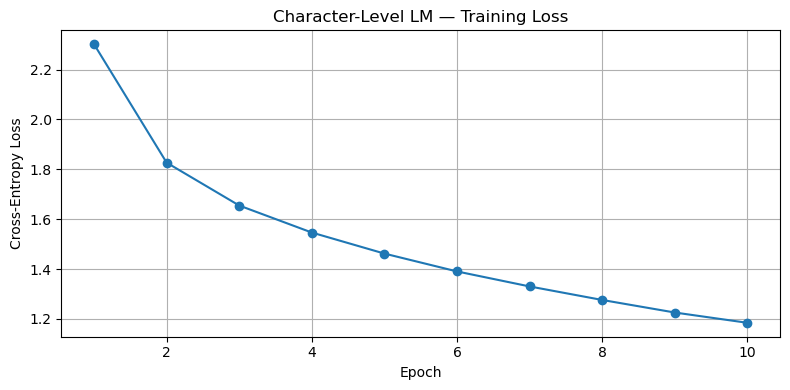

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history["loss"]) + 1), history["loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Character-Level LM — Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

### Q1.9 - Perplexity for Language Models

Implement a function `calculate_perplexity` for your trained character-level language model.

It should:
1. run the model over the full dataset
2. accumulate the summed negative log-likelihood
3. divide by the total number of target characters
4. exponentiate the average loss to obtain perplexity

Because we only have one small corpus here, compute perplexity on the training data.

**Note:** For language models, perplexity is just exp(average cross-entropy loss). Lower perplexity indicates that the model assigns higher probability to the observed next characters.

In [17]:
def calculate_perplexity(model, data_loader):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="sum")
    total_nll = 0.0
    total_tokens = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            total_nll += criterion(logits, yb).item()
            total_tokens += yb.size(0)
    model.train()
    return math.exp(total_nll / total_tokens)

perplexity = calculate_perplexity(lm_model, char_loader)

In [18]:
print(f"Train Perplexity: {perplexity:.2f}")

Train Perplexity: 2.82


### Q1.10 - Model Assessment

Write a seed string of length `SEQ_LEN` and use it to generate at least 400 additional characters at three different temperatures.

Then discuss:
- the architecture and hyperparameter choices you settled on
- what seemed to help or hurt according to loss, perplexity, and generated text quality
- how well the model captures the whimsical Edward Lear style


In [19]:
start = text.find("there was an old man with a beard") # passage picked as seed
seed_str = text[start:start + SEQ_LEN] # make the seed string of length SEQ_LEN
assert len(seed_str) == SEQ_LEN, f"seed must be {SEQ_LEN} chars, got {len(seed_str)}"  # check length

print(f"Seed ({SEQ_LEN} chars):\n{seed_str}\n")

lm_model.eval()
for temperature in [0.2, 0.5, 1.0]:
    current = list(seed_str)
    generated = ""
    for _ in range(400):
        enc = np.array([[char2idx[c] for c in current[-SEQ_LEN:]]])
        x_in = torch.tensor(enc, dtype=torch.long).to(DEVICE)
        with torch.no_grad():
            logits = lm_model(x_in)
            probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        next_idx = sample(probs, temperature=temperature)
        next_char = idx2char[next_idx]
        generated += next_char
        current.append(next_char)
    print(f"\n=== Temperature {temperature} ===")
    print(generated)
lm_model.train()

Seed (100 chars):
there was an old man with a beard, who sat on a horse when he reared; but they said, "never mind! yo


=== Temperature 0.2 ===
u will not see!" that was all the water, which was so still to the top of the town with a little carmer of the town to the seven young geese. there was an old man of the seven young lady of two old man of the seven young geese. there was an old person of bar, who was so them, and were all the seven young geese. there was an old man of the seven young geese. there was an old man of the seven young 

=== Temperature 0.5 ===
u are!" when they said, "if you wish, you are, you are!" when they said, "you children that in eillong, you are, you are!" so they said, "if you chinstair and seven young lady of portuous old man of the sea!" he was all his seven young geese. there was an old man of the wilderly, that leather sparrows, and conclanged all the gooseberry ears they said, "that only dix it not, goose it was made in a 

=== Temperature 1.0 ===
ur'

CharLM(
  (embedding): Embedding(56, 64)
  (rnn): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=56, bias=True)
)

<!-- ANSWER-BOUNDARY-START -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


**Architecture and hyperparameters choices:**  
The model uses a 2-layer LSTM with a 64-dim embedding and 256 hidden units per layer (dropout 0.3), trained with Adam (lr=1e-3) for 10 epochs at batch size 256 and sequence length 100

**Impact of hyperparameters:**  
- **Depth (2 layers)** : improved loss compared to a single-layer LSTM by giving the model more capacity to learn longer-range patterns
- **Temperature** : at 0.2 the text is repetitive but grammatically plausible, at 1.0 it is more creative but produces more nonsense (impact on generated text quality here)
- **Epochs** : training for more epochs continued to reduce both loss and perplexity, though gains slowed after around 7 epochs
- **Hidden size** : a larger hidden size (512) barely moved perplexity on this small corpus while doubling training time

**Edward Lear style:**  
At low temperature the model picks up Lear's limerick-like rhythm and recurring phrases ("there was an old man…"). At higher temperatures it invents plausible-sounding nonsense words reminiscent of Lear's invented vocabulary. I would say that the model does not reliably produce coherent rhymes because it sees only the last 100 characters and cannot plan ahead to enforce a rhyme scheme.

<!-- ANSWER-BOUNDARY-END -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


<a id="part2"></a>

## Part II: Named Entity Recognition

Named entity recognition (NER) seeks to locate and classify named entities present in unstructured text into categories such as organizations, locations, times, persons, and so on.

In this part, you will preprocess a tagged sequence dataset, convert it to padded integer representations, train a bidirectional recurrent model in PyTorch, inspect its learned latent representations, and analyze performance using class-wise F1 scores.


In [20]:
# Load the NER data
file_path = "https://storage.googleapis.com/cs109b/nlp/ner_dataset.csv"
data = pd.read_csv(file_path, encoding="latin1", na_values=[''], keep_default_na=False) 
## change of the row above because issue with the word 'None' otherwise
data = data.fillna(method="ffill")
print("Shape:", data.shape)
data.head(15)

Shape: (1048575, 4)


,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O
5,Sentence: 1,through,IN,O
6,Sentence: 1,London,NNP,B-geo
7,Sentence: 1,to,TO,O
8,Sentence: 1,protest,VB,O
9,Sentence: 1,the,DT,O


### Q2.1.1 - Creating the Vocabulary

Create a sorted list `words` of unique tokens found in the `'Word'` column. Store the length of this list as `n_words`, and print `n_words`.

**Note:** Do not modify capitalization and do not remove numerical or special characters.


In [21]:
words = sorted(data['Word'].unique().tolist())
n_words = len(words)

In [22]:
print("n_words:", n_words)

n_words: 35178


### Q2.1.2 - Unique Tags

Create a sorted list `tags` of the unique values in the `'Tag'` column. Store the length of this list as `n_tags`, and print it.


In [23]:
tags = sorted(data['Tag'].unique().tolist())
n_tags = len(tags)

In [24]:
print("n_tags:", n_tags)

n_tags: 17


### Q2.1.3 - Sentences of Input-Target Pairs

Process the dataframe into a list called `sentences`, where each element is itself a list of `(word, tag)` tuples for a single sentence.

**Note:** The raw dataframe is at the token level, not the sentence level. Before building a sequence model, you need to regroup the rows so that each sentence becomes a list of (word, tag) pairs in the original order.

In [25]:
sentences = []
for _, group in data.groupby(data['Sentence #'].ne(data['Sentence #'].shift()).cumsum()):
    sentences.append(list(zip(group['Word'].tolist(), group['Tag'].tolist())))

In [26]:
sentences[0]

[('Thousands', 'O'),
 ('of', 'O'),
 ('demonstrators', 'O'),
 ('have', 'O'),
 ('marched', 'O'),
 ('through', 'O'),
 ('London', 'B-geo'),
 ('to', 'O'),
 ('protest', 'O'),
 ('the', 'O'),
 ('war', 'O'),
 ('in', 'O'),
 ('Iraq', 'B-geo'),
 ('and', 'O'),
 ('demand', 'O'),
 ('the', 'O'),
 ('withdrawal', 'O'),
 ('of', 'O'),
 ('British', 'B-gpe'),
 ('troops', 'O'),
 ('from', 'O'),
 ('that', 'O'),
 ('country', 'O'),
 ('.', 'O')]

### Q2.1.4 - Maximum Sentence Length

Find the number of words in the longest sentence and store it as `max_len`. Print the result.


In [27]:
max_len = max(len(s) for s in sentences)

In [28]:
print("max_len:", max_len)

max_len: 104


### Q2.1.5 - Word Encoding

Create:
- `word2idx`, a dictionary mapping each distinct word to an integer
- `idx2word`, the inverse mapping

**Important:** start indices at `1` and reserve `0` for padding.


In [29]:
word2idx = {w: i + 1 for i, w in enumerate(words)}
idx2word = {i + 1: w for i, w in enumerate(words)}

### Q2.1.6 - Prepare X

Construct `X` as a list of lists, where each inner list is a sentence encoded as word indices using `word2idx`.


In [30]:
X = [[word2idx[w] for w, t in s] for s in sentences]

### Q2.1.7 - Pad X

Pad all encoded input sentences to length `max_len` using left-padding with `0`, and convert the result to a numpy array called `X`.

**Note:** Because this is a sequence labeling task, you must pad both the input word sequences and the target tag sequences to the same length. If a real word is at position j in X, its corresponding real tag should also be at position j in y. Reserve 0 for padding in both cases so that the padded positions can later be ignored in the loss and metrics.


In [31]:
X = np.array([[0] * (max_len - len(seq)) + seq for seq in X], dtype=np.int32)

In [32]:
print("Sentence 1:", X[0])
print("X shape:", X.shape)

Sentence 1: [    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0 15078 27701 20970 24219
 26435 33390  9685 33465 29397 33247 34661 24854  8205 17365 20925 33247
 34974 27701  4011 33787 23513 33243 20369    25]
X shape: (47959, 104)


### Q2.1.8 - Tag Encoding

Create:
- `tag2idx`, a dictionary mapping each named-entity tag to an integer
- `idx2tag`, the inverse mapping

**Important:** start indices at `1` and reserve `0` for padding.


In [33]:
tag2idx = {t: i + 1 for i, t in enumerate(tags)}
idx2tag  = {i + 1: t for i, t in enumerate(tags)}

### Q2.1.9 - Prepare Y

Construct `y` as a list of lists, where each inner list is a sentence's tag sequence encoded with `tag2idx`.


In [34]:
y = [[tag2idx[t] for w, t in s] for s in sentences]

### Q2.1.10 - Pad Y

Pad all encoded target sequences to length `max_len` using left-padding with `0`, and convert the result to a numpy array called `y`.


In [35]:
y = np.array([[0] * (max_len - len(seq)) + seq for seq in y], dtype=np.int32)

In [36]:
print("y shape:", y.shape)
print("Example target row:", y[0])

y shape: (47959, 104)
Example target row: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 17 17 17 17 17 17  3 17 17 17 17 17  3 17 17 17
 17 17  4 17 17 17 17 17]


### Q2.1.11 - Train / Validation / Test Split

Construct train, validation, and test splits by:
1. splitting off 10% for test
2. then splitting 10% of the remainder for validation

Use `random_state = 109` for both calls to `train_test_split`.

Then create three PyTorch `DataLoader`s called:
- `ner_train_loader`
- `ner_val_loader`
- `ner_test_loader`


In [37]:
# 10 % for test
X_tr_and_val, X_test, y_tr_and_val, y_test = train_test_split(X, y, test_size=0.10, random_state=109)
# 10 % of remainder for validation
X_train, X_val, y_train, y_val = train_test_split(X_tr_and_val, y_tr_and_val, test_size=0.10, random_state=109)

def make_ner_loader(X_arr, y_arr, batch_size=64, shuffle=False):
    ds = TensorDataset(torch.tensor(X_arr, dtype=torch.long),torch.tensor(y_arr, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

ner_train_loader = make_ner_loader(X_train, y_train, shuffle=True)
ner_val_loader = make_ner_loader(X_val, y_val)
ner_test_loader = make_ner_loader(X_test, y_test)

In [38]:
print("train size:", len(X_train))
print("val size:", len(X_val))
print("test size:", len(X_test))

train size: 38846
val size: 4317
test size: 4796


### Q2.2.1 - Build and Fit the NER Model

Build a recurrent NER model in PyTorch with the following components:

- an embedding layer with output dimension `50`
- a dropout layer
- a bidirectional GRU with hidden size `100` in each direction
- a final linear layer producing logits over all possible tags

Because this is a sequence tagging problem, the model should return logits for every timestep.

Define:
- `ner_model`
- `ner_criterion`
- `ner_optimizer`

Then train the model, save the best checkpoint, and plot the training history.

**Note:** Unlike the section sentiment models, this is a many-to-many problem. The model should return logits for every timestep, so its output should have shape (batch_size, seq_len, n_tags_plus_padding), not just one prediction per sentence. Since 0 is reserved for padding in the tag sequences, use a loss that ignores padded positions, such as `CrossEntropyLoss(ignore_index=0)`.

In [39]:
class NERModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, n_tags, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.bigru = nn.GRU(embed_dim, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, n_tags)

    def forward(self, x, return_hidden=False):
        emb = self.dropout(self.embedding(x))
        out, _ = self.bigru(emb)
        logits = self.fc(out)
        if return_hidden:
            return logits, out
        return logits

# +1 for padding index 0
ner_model = NERModel(vocab_size = n_words + 1, embed_dim = 50, hidden_size = 100, n_tags = n_tags + 1, dropout = 0.3).to(DEVICE) 

# compute inverse-frequency weights: rare tags get higher weight, common tags lower weight
# this forces the model to pay attention to minority entity classes, not just predict O
tag_counts = np.bincount(y_train.flatten(), minlength=n_tags + 1).astype(np.float32)
tag_counts[0] = 1  # avoid division by zero for padding
weights = 1.0 / tag_counts
weights[0] = 0.0   # zero weight for padding
weights = weights / weights[1:].sum()
weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
ner_criterion = nn.CrossEntropyLoss(ignore_index=0, weight=weights)

ner_optimizer = torch.optim.Adam(ner_model.parameters(), lr=1e-3)

In [40]:
print(ner_model)
with torch.no_grad():
    sample_logits = ner_model(next(iter(ner_train_loader))[0][:4].to(DEVICE))
print("sample logits shape:", tuple(sample_logits.shape))

NERModel(
  (embedding): Embedding(35179, 50, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (bigru): GRU(50, 100, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=200, out_features=18, bias=True)
)
sample logits shape: (4, 104, 18)


In [41]:
NER_CKPT = ARTIFACTS_DIR / "ner_best.pt"
NER_HISTORY = ARTIFACTS_DIR / "ner_history.pkl"
NER_EPOCHS = 15

def ner_eval(model, loader):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = ner_criterion(logits.view(-1, n_tags + 1), yb.view(-1))
            mask = yb.view(-1) != 0
            total_loss   += loss.item() * mask.sum().item()
            total_tokens += mask.sum().item()
    model.train()
    return total_loss / max(total_tokens, 1)

if NER_CKPT.exists() and NER_HISTORY.exists():
    ner_model.load_state_dict(torch.load(NER_CKPT, map_location=DEVICE))
    with open(NER_HISTORY, "rb") as f:
        ner_history = pickle.load(f)
    print(f"Loaded NER checkpoint. Epochs: {len(ner_history['train_loss'])}")
else:
    ner_history = {"train_loss": [], "val_loss": []}
    best_val = float("inf")

    for epoch in range(1, NER_EPOCHS + 1):
        ner_model.train()
        total_loss, total_tokens = 0.0, 0
        for xb, yb in ner_train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            ner_optimizer.zero_grad()
            logits = ner_model(xb)
            loss = ner_criterion(logits.view(-1, n_tags + 1), yb.view(-1)) # flatten batch and sequence dimensions together
            loss.backward()
            torch.nn.utils.clip_grad_norm_(ner_model.parameters(), 5.0) # gradient clipping
            ner_optimizer.step()
            mask = yb.view(-1) != 0 # mask for padding
            total_loss   += loss.item() * mask.sum().item()
            total_tokens += mask.sum().item()

        train_loss = total_loss / max(total_tokens, 1)
        val_loss   = ner_eval(ner_model, ner_val_loader)
        ner_history["train_loss"].append(train_loss)
        ner_history["val_loss"].append(val_loss)
        print(f"Epoch {epoch:2d}/{NER_EPOCHS} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(ner_model.state_dict(), NER_CKPT)

    ner_model.load_state_dict(torch.load(NER_CKPT, map_location=DEVICE))
    with open(NER_HISTORY, "wb") as f:
        pickle.dump(ner_history, f)
    print(f"Best val loss: {best_val:.4f} — checkpoint saved.")

Loaded NER checkpoint. Epochs: 15


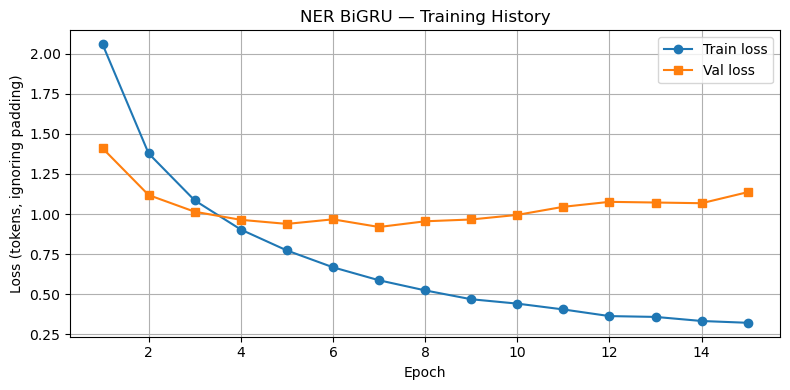

In [42]:
epochs = range(1, len(ner_history["train_loss"]) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, ner_history["train_loss"], marker="o", label="Train loss")
plt.plot(epochs, ner_history["val_loss"],   marker="s", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (tokens, ignoring padding)")
plt.title("NER BiGRU — Training History")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Q2.2.2 - Visualizing the Latent Space

Visualize the hidden representations learned by your bidirectional GRU.

Create a 2D PCA projection of the hidden states from the recurrent layer, and make two subplots:
- one for `B-` tags
- one for `I-` tags

Then comment on any visible structure or overlap.

**Note:** When analyzing hidden states, exclude padded positions. The PCA should reflect the model’s representations of real tokens, not artificial padding tokens.


In [43]:
# Helper functions
def visualize_B_I(pca_result, y_flat):
    tag_names = np.array([idx2tag[int(idx)] for idx in y_flat])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, prefix in zip(axes, ["B-", "I-"]):
        tags_this_panel = sorted({t for t in tag_names if t.startswith(prefix)})
        for tag in tags_this_panel:
            idx = np.where(tag_names == tag)[0]
            ax.scatter(
                pca_result[idx, 0],
                pca_result[idx, 1],
                s=4,
                alpha=0.5,
                label=tag,
            )
        ax.set_title(f"{prefix} tags")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend(markerscale=3, fontsize=8)

    plt.suptitle("PCA of BiGRU Hidden States")
    plt.tight_layout()
    plt.show()

def get_hidden_output_pca(model, X_test, y_test, max_points=20000):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_test, dtype=torch.long, device=DEVICE)
        _, hidden = model(X_tensor, return_hidden=True)

    hidden = hidden.cpu().numpy().reshape(-1, hidden.shape[-1])
    y_flat = y_test.reshape(-1)

    mask = y_flat != 0
    hidden = hidden[mask]
    y_flat = y_flat[mask]

    if len(y_flat) > max_points:
        idx = np.random.choice(len(y_flat), size=max_points, replace=False)
        hidden = hidden[idx]
        y_flat = y_flat[idx]

    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(hidden)
    print(f"Variance explained by first 2 PCs: {pca.explained_variance_ratio_.sum():.4f}")
    return pca_result, y_flat

Variance explained by first 2 PCs: 0.1365


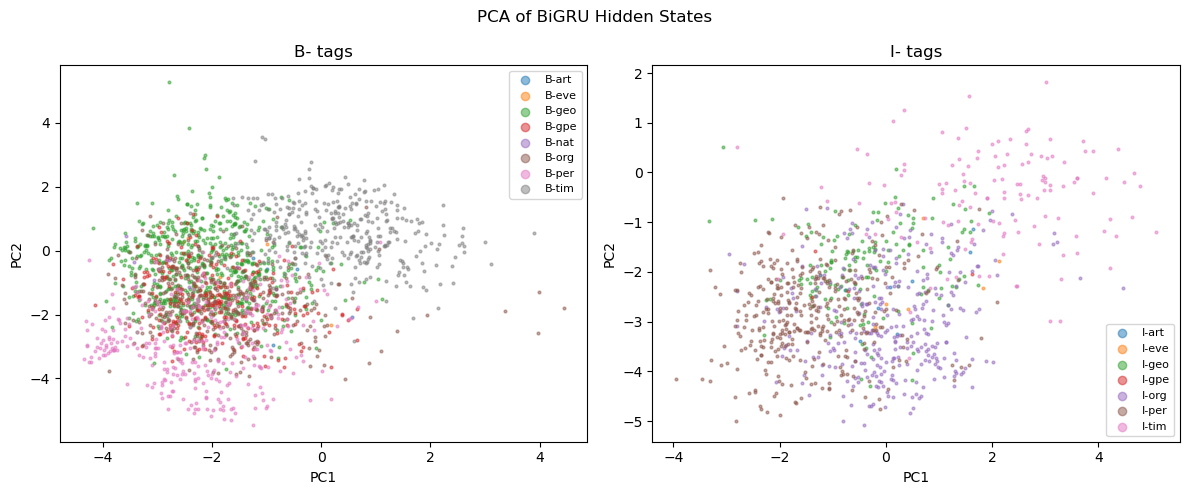

In [44]:
pca_result, y_flat = get_hidden_output_pca(ner_model, X_test, y_test)
visualize_B_I(pca_result, y_flat)

<!-- ANSWER-BOUNDARY-START -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


**Latent-space structure:**

The PCA projection of the BiGRU hidden states reveals limited separability between entity types in 2D space. Only **13.56%** of the total variance is captured by the first two principal components, indicating that the meaningful structure in the 200-dimensional hidden space is largely lost in this projection.

The *B-* plot shows more visible structure than the I- plot: *B-per* (pink) forms a loose cluster in the lower region, while *B-tim* (grey) spreads distinctly toward the upper area. *B-geo* and *B-gpe* overlap heavily in the center, which is consistent with their semantic similarity (both refer to geographic or political entities). Rarer tags (*B-art*, *B-eve*, *B-nat*) are barely visible due to their very low frequency.

The *I-* plot is more diffuse overall, with *I-per* and *I-geo* being the most visible but still heavily overlapping. This is expected because continuation tokens are more lexically diverse and harder to cluster.

Overall, the limited separability is explained by two factors: the high dimensionality of the hidden states making 2D projection insufficient, and the dominance of the O tag (around 83% of tokens) which pushes the model to allocate most representational capacity to the majority class.

<!-- ANSWER-BOUNDARY-END -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


### Q2.3.1 - Computing & Plotting F1 Scores

Use your trained NER model to predict on the test set. Compute an F1 score for each tag category (excluding padding) and store the result in `f1_scores`.

Then create a well-labeled bar plot showing the per-tag F1 scores.

**Note:** Compute F1 scores at the token level after masking out padding, not at the sentence level. Padding should not be treated as a class, and it should not contribute to the metric.

In [45]:
ner_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for xb, yb in ner_test_loader:
        xb = xb.to(DEVICE)
        logits = ner_model(xb)
        preds  = logits.argmax(dim=-1).cpu().numpy()
        labels = yb.numpy()
        mask   = labels != 0  # ignore padding positions
        all_preds.extend(preds[mask].tolist())
        all_labels.extend(labels[mask].tolist())

all_preds  = [p if p != 0 else 1 for p in all_preds]

pred_tags  = [idx2tag[p] for p in all_preds]
label_tags = [idx2tag[l] for l in all_labels]
unique_tags = sorted(set(label_tags))

f1_scores = f1_score(label_tags, pred_tags, labels=unique_tags, average=None)
print(classification_report(label_tags, pred_tags, labels=unique_tags))

              precision    recall  f1-score   support

       B-art       0.01      0.32      0.02        38
       B-eve       0.06      0.59      0.10        32
       B-geo       0.61      0.82      0.70      3731
       B-gpe       0.65      0.89      0.76      1549
       B-nat       0.05      0.76      0.09        25
       B-org       0.35      0.66      0.46      1984
       B-per       0.45      0.76      0.56      1798
       B-tim       0.41      0.88      0.56      2017
       I-art       0.02      0.23      0.03        35
       I-eve       0.05      0.43      0.09        28
       I-geo       0.28      0.76      0.41       750
       I-gpe       0.03      0.45      0.05        20
       I-nat       0.14      0.50      0.22        10
       I-org       0.32      0.74      0.45      1723
       I-per       0.61      0.81      0.70      1777
       I-tim       0.19      0.85      0.31       697
           O       1.00      0.81      0.89     88422

    accuracy              

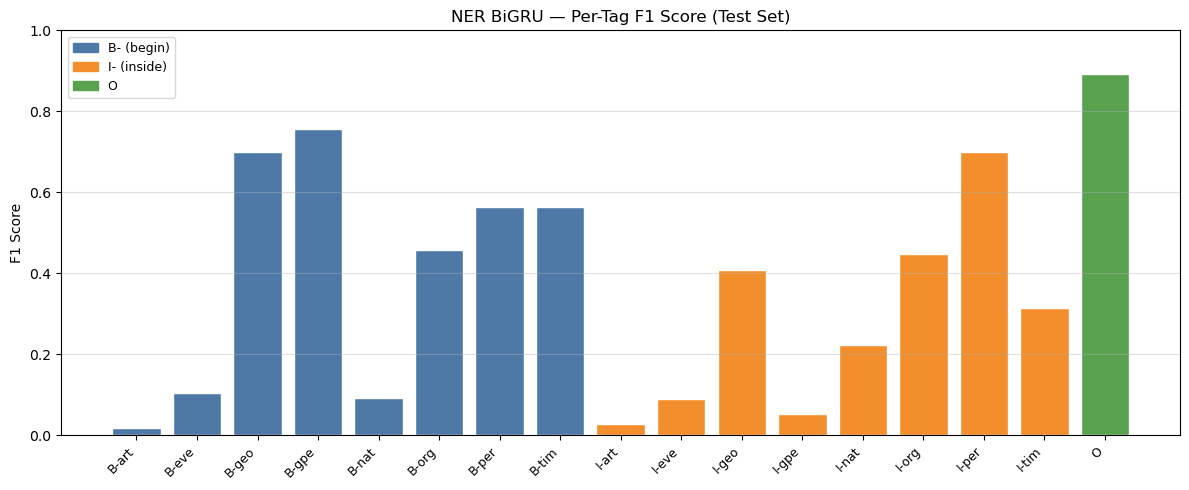

In [46]:
plt.figure(figsize=(12, 5))
colors = ["#4e79a7" if t.startswith("B-") else "#f28e2b" if t.startswith("I-") else "#59a14f"
          for t in unique_tags]
bars = plt.bar(unique_tags, f1_scores, color=colors, edgecolor="white")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylabel("F1 Score")
plt.title("NER BiGRU — Per-Tag F1 Score (Test Set)")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.4)
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color="#4e79a7", label="B- (begin)"),
    Patch(color="#f28e2b", label="I- (inside)"),
    Patch(color="#59a14f", label="O"),
], fontsize=9)
plt.tight_layout()
plt.show()

### Q2.3.2 - Discussion

Briefly discuss the model's performance across tag categories. Does anything stand out in the class-wise F1 scores or the latent-space visualization? If so, what could be done in future iterations to address it?


<!-- ANSWER-BOUNDARY-START -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


The model achieves **81%** overall accuracy and a weighted F1 of **0.84**, which are solid results for a BiGRU trained from scratch without pretrained embeddings.

Performance varies strongly across tag categories and correlates directly with frequency. High-frequency tags like *B-geo* (F1=0.70), *B-gpe* (0.76), *B-per* (0.56) and *B-tim* (0.56) are learned well. The O tag reaches **F1=0.89** with perfect precision (1.00), meaning every O prediction is correct. In contrast, rare tags like *B-art* (0.02), *B-eve* (0.10) and *B-nat* (0.09) are nearly unlearnable, with fewer than 40 test examples each, the model has almost no signal to distinguish them.

Two additional patterns stand out: B- tags consistently outperform their I- counterparts (with the only exception of B-per=0.56 vs I-per=0.70), and precision is generally lower than recall, meaning the model over-predicts entity tags. This is a direct effect of the inverse-frequency weighting which encourages the model to predict minority classes more aggressively.

Future improvements could include:
- **Pretrained embeddings** to give the model richer word representations, especially for rare entities
- **A CRF layer** on top of the BiGRU to enforce valid tag transition constraints (e.g. I-per cannot follow B-geo)
- **Softer class weighting** (e.g. square-root instead of inverse frequency) to reduce over-prediction of rare tags while still handling imbalance

<!-- ANSWER-BOUNDARY-END -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


<a id="part3"></a>

## Part III: Transformer-Based Text Classification

In this part, you will fine-tune a pretrained transformer for abstract classification. You will first work with BERT and then, for the graduate extension, optionally compare it to DeBERTa.

The goal is to classify whether an abstract is irrelevant (`0`) or not irrelevant (`1`).


### Q3.1 - Loading the Abstract Data

Load the CSV files:
- `review_78678_irrelevant.csv`
- `review_78678_not_irrelevant_included.csv`
- `review_78678_not_irrelevant_excluded.csv`

into three pandas DataFrames from the local `data/` directory.

Add a new column called `target` with:
- `0` for the irrelevant dataframe
- `1` for the two not-irrelevant dataframes


In [47]:
irrelevant_df = pd.read_csv(DATA_ROOT / "review_78678_irrelevant.csv")
included_df   = pd.read_csv(DATA_ROOT / "review_78678_not_irrelevant_included.csv")
excluded_df   = pd.read_csv(DATA_ROOT / "review_78678_not_irrelevant_excluded.csv")

irrelevant_df['target'] = 0
included_df['target'] = 1
excluded_df['target'] = 1

### Q3.2 - Combine the DataFrames

Concatenate all three dataframes into a single dataframe called `all_data_df`.

Keep only the columns `Abstract` and `target`, then apply `dropna()`.


In [48]:
all_data_df = pd.concat([irrelevant_df, included_df, excluded_df], ignore_index=True)
all_data_df = all_data_df[['Abstract', 'target']].dropna()

In [49]:
print("Shape:", all_data_df.shape)
print(all_data_df["target"].value_counts(normalize=True))
all_data_df.head()

Shape: (4318, 2)
target
0    0.874016
1    0.125984
Name: proportion, dtype: float64


,Abstract,target
0,This study was carried out to know the prevale...,0
1,We attempted to determine the seropositivity o...,0
2,Human herpesvirus 8 (HHV-8) infection is commo...,0
3,338 women with age ranging from 15 to 69 years...,0
4,Antenatal screening and treatment for sexually...,0


### Q3.3 - Train / Validation Split

Use `train_test_split` to split the data into:
- `train_x`, `train_y`
- `validate_x`, `validate_y`

Use a 90% / 10% split, stratify on the target, and set `random_state = 109`.


In [50]:
train_x, validate_x, train_y, validate_y = train_test_split(
    all_data_df['Abstract'].tolist(),
    all_data_df['target'].tolist(),
    test_size=0.10,
    stratify=all_data_df['target'],
    random_state=109,
)

In [51]:
print("train size:", len(train_x))
print("validation size:", len(validate_x))

train size: 3886
validation size: 432


### Q3.4 - BERT Tokenization

Load the tokenizer for `'bert-base-uncased'` using `AutoTokenizer`.

Then:
- choose a reasonable `max_length` no larger than `512`
- tokenize both the training and validation abstracts
- store the tokenized outputs as `train_x_processed` and `validate_x_processed`

Be sure the resulting tokenized objects contain at least:
- `input_ids`
- `attention_mask`

**Note:** Unlike the earlier sequence models, these transformers require a specific tokenizer to be used. The tokenizer converts each abstract into integer token IDs and also creates an `attention_mask`, which tells the model which positions are real tokens and which are just padding. Truncation and padding are both necessary here so that examples in the same batch all have the same length.

In [52]:
tokenizer_bert = AutoTokenizer.from_pretrained('bert-base-uncased')

max_length = 256

train_x_processed = tokenizer_bert(
    train_x,
    max_length=max_length,
    padding='max_length',
    truncation=True,
    return_tensors='pt',
)
validate_x_processed = tokenizer_bert(
    validate_x,
    max_length=max_length,
    padding='max_length',
    truncation=True,
    return_tensors='pt',
)

In [53]:
print("max_length:", max_length)
print(train_x_processed.keys())
print("train input_ids shape:", tuple(train_x_processed["input_ids"].shape))
print("validation input_ids shape:", tuple(validate_x_processed["input_ids"].shape))

max_length: 256
dict_keys(['input_ids', 'token_type_ids', 'attention_mask'])
train input_ids shape: (3886, 256)
validation input_ids shape: (432, 256)


### Q3.5 - PyTorch Dataset / DataLoader Pipeline

Build PyTorch datasets and dataloaders for the BERT task.

Create:
- a dataset class that returns `input_ids`, `attention_mask`, and `labels`
- a training dataloader called `train_loader`
- a validation dataloader called `validation_loader`

Use batch size `16`.

**Note:** For Hugging Face classification models, each batch is usually a dictionary containing tensors such as `input_ids`, `attention_mask`, and `labels`, rather than a simple (X, y) pair like in some earlier PyTorch examples.


In [54]:
class AbstractDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_dataset = AbstractDataset(train_x_processed, train_y)
val_dataset = AbstractDataset(validate_x_processed, validate_y)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
validation_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [55]:
print("train_loader batches:", len(train_loader))
print("validation_loader batches:", len(validation_loader))
batch = next(iter(train_loader))
print({k: tuple(v.shape) for k, v in batch.items()})

train_loader batches: 243
validation_loader batches: 27
{'input_ids': (16, 256), 'attention_mask': (16, 256), 'labels': (16,)}


### Q3.6 - Build Pre-Trained BERT

Load the pretrained `'bert-base-uncased'` model for sequence classification in PyTorch.

Define:
- `bert_model`
- `bert_optimizer`

Use an appropriate optimizer and learning rate for fine-tuning. Display the model and report the number of trainable parameters.

**Note:** In section, BERT was used mainly to illustrate contextual embeddings. Here, you are doing fine-tuning: starting from a pretrained model and then updating its weights on your classification task, rather than just using frozen embeddings as input to a separate model.

This is still a binary classification problem, but in this homework we use the standard Hugging Face two-logit formulation (`num_labels=2`) rather than a single-logit sigmoid formulation.


In [56]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
).to(DEVICE)

# AdamW with small LR — standard for BERT fine-tuning
bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)

n_trainable_params = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [57]:
print(bert_model)
print(f"Trainable parameters: {n_trainable_params:,}")

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

### Q3.7 - Fit BERT to the Classification Task

Train BERT while monitoring validation performance.

Your solution should:
- save the best checkpoint
- avoid retraining if a saved checkpoint already exists
- track at least training loss, validation loss, and validation accuracy
- plot the training history

**Note:** Fine-tuning a transformer is much more expensive than fitting the earlier RNN models, so you should save checkpoints and reload them on reruns rather than retraining every time. Also note that the Hugging Face classification model returns an object containing both loss and logits when labels are provided. You can use the built-in loss directly during training rather than defining a separate loss function yourself.

In [58]:
BERT_CKPT = ARTIFACTS_DIR / "bert_best.pt"
BERT_HISTORY = ARTIFACTS_DIR / "bert_history.pkl"
BERT_EPOCHS = 4

if BERT_CKPT.exists() and BERT_HISTORY.exists():
    bert_model.load_state_dict(torch.load(BERT_CKPT, map_location=DEVICE))
    with open(BERT_HISTORY, 'rb') as f:
        bert_history = pickle.load(f)
    print(f"Loaded BERT checkpoint. Epochs: {len(bert_history['train_loss'])}")
else:
    bert_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')

    for epoch in range(1, BERT_EPOCHS + 1):
        bert_model.train()
        total_loss = 0.0
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            bert_optimizer.zero_grad()
            outputs = bert_model(**batch)
            outputs.loss.backward()
            torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
            bert_optimizer.step()
            total_loss += outputs.loss.item()

        bert_model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for batch in validation_loader:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                outputs = bert_model(**batch)
                val_loss += outputs.loss.item()
                preds     = outputs.logits.argmax(dim=-1)
                correct  += (preds == batch['labels']).sum().item()
                total    += batch['labels'].size(0)

        avg_train = total_loss / len(train_loader)
        avg_val   = val_loss   / len(validation_loader)
        acc       = correct / total
        bert_history['train_loss'].append(avg_train)
        bert_history['val_loss'].append(avg_val)
        bert_history['val_acc'].append(acc)
        print(f"Epoch {epoch}/{BERT_EPOCHS} | train_loss {avg_train:.4f} | val_loss {avg_val:.4f} | val_acc {acc:.4f}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(bert_model.state_dict(), BERT_CKPT)

    bert_model.load_state_dict(torch.load(BERT_CKPT, map_location=DEVICE))
    with open(BERT_HISTORY, 'wb') as f:
        pickle.dump(bert_history, f)
    print(f"Best val loss: {best_val_loss:.4f} — checkpoint saved.")

Loaded BERT checkpoint. Epochs: 4


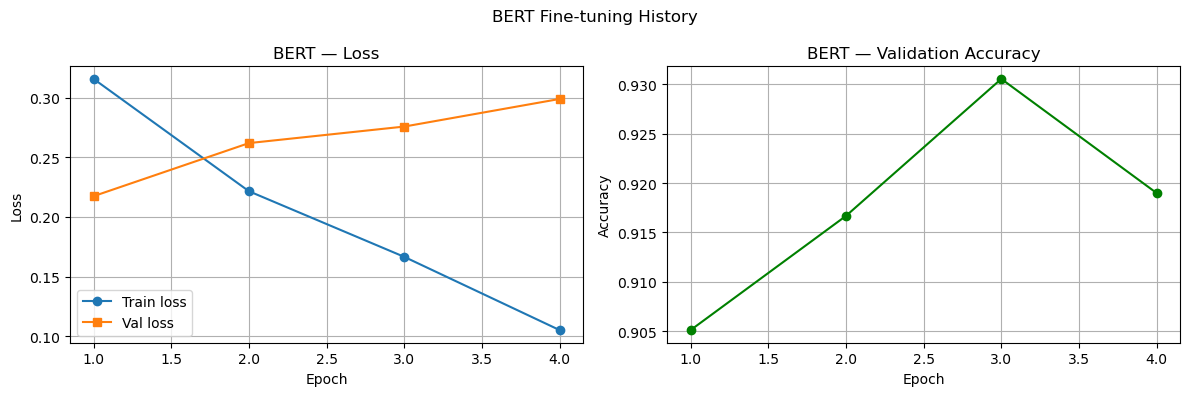

In [59]:
epochs = range(1, len(bert_history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, bert_history['train_loss'], marker='o', label='Train loss')
ax1.plot(epochs, bert_history['val_loss'],   marker='s', label='Val loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('BERT — Loss'); ax1.legend(); ax1.grid(True)

ax2.plot(epochs, bert_history['val_acc'], marker='o', color='green')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('BERT — Validation Accuracy'); ax2.grid(True)

plt.suptitle('BERT Fine-tuning History')
plt.tight_layout()
plt.show()

### Q3.8 - BERT Model Results

Use the validation set to:
- display a confusion matrix
- decode and display 2 abstracts the model considered highly *irrelevant*
- decode and display 2 abstracts the model considered highly *not irrelevant*

Then comment on the confusion matrix, the decoded examples, and the training history.


**Note:** High-confidence predictions are worth inspecting qualitatively. A model can be very confident for the wrong reason, so reading a few strongly predicted examples is a useful sanity check in addition to looking at aggregate metrics.

In [60]:
bert_model.eval()
all_probs = []
with torch.no_grad():
    for batch in validation_loader:
        batch   = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = bert_model(**batch)
        probs   = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        all_probs.extend(probs)

bert_probs = np.array(all_probs)
bert_preds = bert_probs.argmax(axis=1)

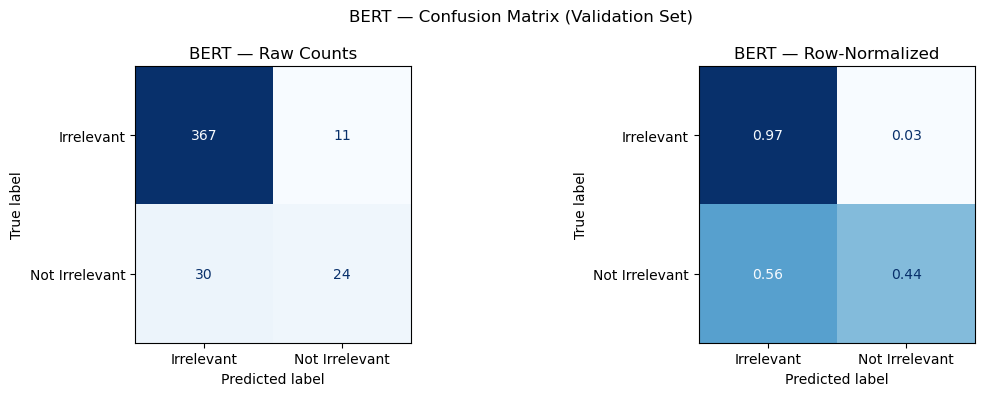

                precision    recall  f1-score   support

    Irrelevant       0.92      0.97      0.95       378
Not Irrelevant       0.69      0.44      0.54        54

      accuracy                           0.91       432
     macro avg       0.81      0.71      0.74       432
  weighted avg       0.89      0.91      0.90       432



In [61]:
cm_raw  = confusion_matrix(validate_y, bert_preds)
cm_norm = confusion_matrix(validate_y, bert_preds, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# raw counts
ConfusionMatrixDisplay(cm_raw, display_labels=['Irrelevant', 'Not Irrelevant']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('BERT — Raw Counts')

# row-normalized (per-class recall)
ConfusionMatrixDisplay(cm_norm, display_labels=['Irrelevant', 'Not Irrelevant']).plot(
    ax=axes[1], cmap='Blues', colorbar=False, values_format='.2f')
axes[1].set_title('BERT — Row-Normalized')

plt.suptitle('BERT — Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.show()
print(classification_report(validate_y, bert_preds, target_names=['Irrelevant', 'Not Irrelevant']))

In [62]:
n_examples = 2
irrelevant_bert = np.argsort(bert_probs[:, 1])[:n_examples]

print("Highest predicted probabilities of being irrelevant\n")
for idx in irrelevant_bert:
    abstract = tokenizer_bert.decode(
        validate_x_processed["input_ids"][idx],
        skip_special_tokens=True,
    )
    print(f"Abstract {idx}: {abstract}\n")

Highest predicted probabilities of being irrelevant

Abstract 215: attitudes to voluntary counselling and testing ( vct ) for hiv among young men and women in a slum area of kampala, uganda, were studied through 22 individual semi - structured interviews and 5 focus group discussions. attitudes to vct ranged from having no problem with the procedure to being very reluctant. despite fear of stigma, the participants perceived'positive living'after hiv testing as realistic. vct was regarded as an important step to avoid hiv infection, but informants expressed the need for the service to be more accessible in terms of cost, time and quality of pre - and post - test counselling. we argue that counselling without hiv testing should be available for those who are reluctant to test. poverty and gender power imbalances appeared to limit youths'possibility of making rational decisions about sexual behaviour and accessing vct. the importance of considering the context in which such issues are bei

In [63]:
not_irrelevant_bert = np.argsort(bert_probs[:, 1])[-n_examples:]

print("Highest predicted probabilities of being NOT irrelevant\n")
for idx in not_irrelevant_bert:
    abstract = tokenizer_bert.decode(
        validate_x_processed["input_ids"][idx],
        skip_special_tokens=True,
    )
    print(f"Abstract {idx}: {abstract}\n")

Highest predicted probabilities of being NOT irrelevant

Abstract 140: to study the prevalence of cervical squamous intraepithelial lesions ( sils ) and their association with hiv - 1 infection and immunodeficiency among pregnant women in kigali, rwanda. as part of a cohort study on the impact of hiv - 1 infection on pregnancy outcome, hiv - 1 seropositive ( hiv + ) and seronegative ( hiv - ) pregnant women were enrolled during the last trimester of pregnancy at the maternity ward of the centre hospitalier de kigali from july 1992 to august 1993. at inclusion, women were screened for sexually transmitted diseases ( stds ) - - syphilis, neisseria gonorrhoeae, chlamydia trachomatis, trichomonas vaginalis. cd4 + lymphocyte counts were measured and a papanicolaou smear performed. papanicolaou smear was interpretable in 103 hiv + women and 107 hiv - women. prevalence of sils was significantly higher in hiv + women than in hiv - women : 24. 3 % v 6. 5 % ( odds ratio = 4. 6 ; 95 % ci : 1. 8 -

<!-- ANSWER-BOUNDARY-START -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


**Training history:**
The training loss decreases steadily across all 4 epochs (0.32 → 0.10), showing the model is learning effectively. However, the validation loss increases after epoch 1 (0.22 → 0.30) while validation accuracy peaks at epoch 3 (93.1%) before dropping, a clear sign of overfitting starting from epoch 2. The best checkpoint was correctly saved at epoch 1 (val loss = 0.2174). With only 432 validation samples and 109M parameters, this rapid overfitting is expected.

**Confusion matrix:**
The model performs strongly on the majority irrelevant class (F1=0.95, 367/378 correct) but struggles with the minority not irrelevant class (F1=0.54, recall=0.44, only 24/54 correctly identified). The 30 false negatives are the main weakness: the class imbalance makes the model conservative about predicting the minority class. The normalized confusion matrix makes this asymmetry clearly visible, showing 97% recall for irrelevant but only 44% recall for not irrelevant.

**Decoded examples:**
- The two highly irrelevant abstracts (215, 218) are about HIV counselling attitudes and MSM healthcare models, related disease area but clearly not matching the specific inclusion criteria of the review (wrong intervention/outcome). BERT correctly identifies the mismatch with high confidence.
- The two highly not-irrelevant abstracts (140, 3) directly report STI prevalence and incidence in HIV-positive women, exactly the type of clinical study a systematic review on this topic would include. BERT correctly flags these, suggesting it has learned to recognize relevant population, intervention, and outcome language from the training abstracts.

Overall, BERT performs well for a model fine-tuned on only ~4000 examples, but the low recall on the minority class means it would miss roughly half of the relevant papers if used as a screening tool, which could be a significant limitation for a systematic review application.

<!-- ANSWER-BOUNDARY-END -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


### Q3.9 - [209] DeBERTa

**All subsequent questions are required for 209 students and optional for others.**

Repeat the tokenization, dataloader construction, model building, and training workflow from Q3.4-Q3.7, but now for the model `'microsoft/deberta-v3-base'`.

You may choose to freeze some early layers if that improves stability.

**Note:** This question follows the same overall fine-tuning pipeline as BERT, but the tokenizer and model should now come from the DeBERTa checkpoint. The main goal is to compare how a different pretrained transformer behaves when the downstream task and training procedure are otherwise similar.


In [64]:

# Tokenization & DataLoaders
# your code here


In [65]:

# Build DeBERTa
# your code here


In [66]:

# Train DeBERTa
# your code here


In [67]:

# Plot Training History
# your code here


### Q3.10 - [209] DeBERTa vs BERT Results

Display confusion matrices for both BERT and DeBERTa, and decode high-confidence examples from both models for:
- the most irrelevant predictions
- the most not-irrelevant predictions


In [68]:

# Predictions
# your code here


In [69]:

# Confusion Matrices
# your code here


In [70]:
'''
n_examples = 2
irrelevant_bert = np.argsort(bert_probs[:, 1])[:n_examples]
irrelevant_deberta = np.argsort(deberta_probs[:, 1])[:n_examples]

print("Highest predicted probabilities of being irrelevant\n")

print("BERT:")
for idx in irrelevant_bert:
    abstract = tokenizer_bert.decode(validate_x_processed["input_ids"][idx], skip_special_tokens=True)
    print(f"Abstract {idx}: {abstract}\n")

print("DeBERTa:")
for idx in irrelevant_deberta:
    abstract = tokenizer_deberta.decode(validate_x_processed_deberta["input_ids"][idx], skip_special_tokens=True)
    print(f"Abstract {idx}: {abstract}\n")
'''

'\nn_examples = 2\nirrelevant_bert = np.argsort(bert_probs[:, 1])[:n_examples]\nirrelevant_deberta = np.argsort(deberta_probs[:, 1])[:n_examples]\n\nprint("Highest predicted probabilities of being irrelevant\n")\n\nprint("BERT:")\nfor idx in irrelevant_bert:\n    abstract = tokenizer_bert.decode(validate_x_processed["input_ids"][idx], skip_special_tokens=True)\n    print(f"Abstract {idx}: {abstract}\n")\n\nprint("DeBERTa:")\nfor idx in irrelevant_deberta:\n    abstract = tokenizer_deberta.decode(validate_x_processed_deberta["input_ids"][idx], skip_special_tokens=True)\n    print(f"Abstract {idx}: {abstract}\n")\n'

In [71]:
'''
not_irrelevant_bert = np.argsort(bert_probs[:, 1])[-n_examples:]
not_irrelevant_deberta = np.argsort(deberta_probs[:, 1])[-n_examples:]

print("Highest predicted probabilities of being NOT irrelevant\n")

print("BERT:")
for idx in not_irrelevant_bert:
    abstract = tokenizer_bert.decode(validate_x_processed["input_ids"][idx], skip_special_tokens=True)
    print(f"Abstract {idx}: {abstract}\n")

print("DeBERTa:")
for idx in not_irrelevant_deberta:
    abstract = tokenizer_deberta.decode(validate_x_processed_deberta["input_ids"][idx], skip_special_tokens=True)
    print(f"Abstract {idx}: {abstract}\n")
'''

'\nnot_irrelevant_bert = np.argsort(bert_probs[:, 1])[-n_examples:]\nnot_irrelevant_deberta = np.argsort(deberta_probs[:, 1])[-n_examples:]\n\nprint("Highest predicted probabilities of being NOT irrelevant\n")\n\nprint("BERT:")\nfor idx in not_irrelevant_bert:\n    abstract = tokenizer_bert.decode(validate_x_processed["input_ids"][idx], skip_special_tokens=True)\n    print(f"Abstract {idx}: {abstract}\n")\n\nprint("DeBERTa:")\nfor idx in not_irrelevant_deberta:\n    abstract = tokenizer_deberta.decode(validate_x_processed_deberta["input_ids"][idx], skip_special_tokens=True)\n    print(f"Abstract {idx}: {abstract}\n")\n'

### Q3.11 - [209] DeBERTa vs BERT Model Comparison

Discuss:
- differences in the training histories
- differences in the confusion matrices and qualitative examples
- whether you used identical hyperparameters / procedures for both models
- two ways in which DeBERTa's positional treatment differs from the absolute positional encoding used in vanilla BERT


**Note:** You are not expected to derive the full transformer internals here. Focus on the big conceptual differences.

<!-- ANSWER-BOUNDARY-START -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


*Your Answer Here*


<!-- ANSWER-BOUNDARY-END -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


## Wrap-up

In a few sentences, describe what you found most challenging about the assignment.

Then store the amount of time you spent on the homework in `hours_spent_on_hw`.


<!-- ANSWER-BOUNDARY-START -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


The most challenging part was Part II. I spent a lot of time understanding the raw data, especially dealing with 'None' string values being silently converted to NaN by pandas. I also struggled with very low F1 scores, the model was completely ignoring the O tag. After a lot of trials, I found that the issue was class imbalance and fixed it by applying inverse-frequency weighting to the loss.

<!-- ANSWER-BOUNDARY-END -->
<div style="background-color:#f0f7ff; border:1px solid #cfe6ff; height:14px; border-radius:8px; margin:10px 0;"></div>


In [72]:
hours_spent_on_hw = 12

In [73]:
# total notebook runtime
minutes_elapsed = (time.time() - time_start) / 60
print(f"Approximate runtime so far: {minutes_elapsed:.2f} minutes")

Approximate runtime so far: 0.47 minutes
